In [7]:
from utils import variables, functions

# realod them (maybe have been updated)
import importlib
importlib.reload(functions)
importlib.reload(variables)

import numpy as np, os, json, pandas as pd, random, pickle, math, re, seaborn as sns
from IPython.display import clear_output
import networkx as nx
import itertools

# Matplotlib
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from matplotlib.patches import Rectangle
import matplotlib.patches as mpatches

# Torch
import torch, torch.nn as nn, torch.optim as optim
import torch.nn.functional as F
from torch_geometric.nn import GCNConv, global_mean_pool, BatchNorm, GATConv
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.utils import dropout_edge

# Sklearn
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression, Ridge, RidgeCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

Functions imported correctly.
Variables imported correctly.


In [8]:
# Load all the dataframes
confounds_df = pd.read_csv(os.path.join(variables.BOLD5000_PATH,'confounds_df.csv'))
rois_df = pd.read_csv(os.path.join(variables.BOLD5000_PATH,'rois_df.csv'))
functionals_df = pd.read_csv(os.path.join(variables.BOLD5000_PATH,'functionals_df.csv'))
events_df = pd.read_csv(os.path.join(variables.BOLD5000_PATH,'events_df.csv'))
trials_df = pd.read_csv(os.path.join(variables.BOLD5000_PATH,'trials_df.csv'))

In [9]:
# Load the images features extracted in feature_extraction.ipynb
data = np.load(os.path.join(variables.BOLD5000_PATH,"image_features_resnet.npz"))
X_features = data['features']
y = data['labels']

print(f'X_features shape: {X_features.shape}')
print(f'y shape: {y.shape}')

X_features shape: (11193, 2048)
y shape: (11193,)


The voxels data are extracted in a format of a feature vector, for each trials, whose length is given by the sum of the number of active voxels of each roi.

To be able to differentiate them in different ROIs, the next few cells will find the boundaries between the ROIs, and create data which are divided in rois.

In [10]:
# Define the boundaries of the different rois
rois_sub1_sizes, rois_sub2_sizes, rois_sub3_sizes, rois_sub4_sizes = {}, {}, {}, {}
for i in range(len(rois_df)):
    if '1' in rois_df['subject'][i]:
        rois_sub1_sizes.update({f"{rois_df['roi'][i]}": int(rois_df['voxels_active'][i])})
    if '2' in rois_df['subject'][i]:
        rois_sub2_sizes.update({f"{rois_df['roi'][i]}": int(rois_df['voxels_active'][i])})
    if '3' in rois_df['subject'][i]:
        rois_sub3_sizes.update({f"{rois_df['roi'][i]}": int(rois_df['voxels_active'][i])})
    if '4' in rois_df['subject'][i]:
        rois_sub4_sizes.update({f"{rois_df['roi'][i]}": int(rois_df['voxels_active'][i])})

roi_aliases = {
    'LHLOC': 'LHLO',
    'RHLOC': 'RHLO',
    'LHRSC': 'LHRRSC',  
    'RHRSC': 'RHRRSC'
}

def normalize_roi_slices(roi_slices, roi_aliases):
    normalized = {}
    for k,v in roi_slices.items():
        normalized[k] = v
    for canonical, alias in roi_aliases.items():
        if alias in roi_slices:
            normalized[canonical] = roi_slices[alias]
    return normalized

# calculate the slices
def build_roi_slices(roi_boundaries):
    roi_names = list(roi_boundaries.keys())
    roi_sizes = list(roi_boundaries.values())
    offsets = np.cumsum([0] + roi_sizes)
    slices = {roi: slice(offsets[i], offsets[i+1]) for i, roi in enumerate(roi_names)}
    return slices

roi_slices_sub1 = normalize_roi_slices(build_roi_slices(rois_sub1_sizes), roi_aliases)
roi_slices_sub2 = normalize_roi_slices(build_roi_slices(rois_sub2_sizes), roi_aliases)
roi_slices_sub3 = normalize_roi_slices(build_roi_slices(rois_sub3_sizes), roi_aliases)
roi_slices_sub4 = normalize_roi_slices(build_roi_slices(rois_sub4_sizes), roi_aliases)

print(roi_slices_sub1)
print(roi_slices_sub2)
print(roi_slices_sub3)
print(roi_slices_sub4)
# {'LH_EarlyVis': slice(0,200, None), 'LH_LOC': slice(200,316, None), ...}
# None is the step. slixe has 3 arguments: start, stop, slice

list_roi_slices = [roi_slices_sub1, roi_slices_sub2, roi_slices_sub3, roi_slices_sub4]

# Each dictionary respects the order of ROIs with which the features have been extracted and concatenated.

{'LHEarlyVis': slice(0, 210, None), 'LHLOC': slice(210, 362, None), 'LHOPA': slice(362, 463, None), 'LHPPA': slice(463, 594, None), 'LHRSC': slice(594, 680, None), 'RHEarlyVis': slice(680, 965, None), 'RHLOC': slice(965, 1155, None), 'RHOPA': slice(1155, 1342, None), 'RHPPA': slice(1342, 1542, None), 'RHRSC': slice(1542, 1685, None)}
{'RHPPA': slice(0, 198, None), 'RHOPA': slice(198, 293, None), 'RHLO': slice(293, 676, None), 'RHEarlyVis': slice(676, 917, None), 'RHRRSC': slice(917, 1058, None), 'LHPPA': slice(1058, 1230, None), 'LHOPA': slice(1230, 1315, None), 'LHLO': slice(1315, 1538, None), 'LHEarlyVis': slice(1538, 1792, None), 'LHRSC': slice(1792, 1851, None), 'LHLOC': slice(1315, 1538, None), 'RHLOC': slice(293, 676, None), 'RHRSC': slice(917, 1058, None)}
{'RHRSC': slice(0, 116, None), 'RHPPA': slice(116, 277, None), 'RHLO': slice(277, 708, None), 'RHEarlyVis': slice(708, 1188, None), 'RHOPA': slice(1188, 1393, None), 'LHPPA': slice(1393, 1505, None), 'LHOPA': slice(1505, 1692,

In [11]:
# Define the order of the sequence of ROIs
roi_order = [
    ('LHEarlyVis','RHEarlyVis'),
    ('LHLOC','RHLOC'),
    ('LHOPA','RHOPA'),
    ('LHPPA','RHPPA'),
    ('LHRSC','RHRSC')
]

RH_order, LH_order = [], []

for roi_pair in roi_order:
    LH_order.append(roi_pair[0])
    RH_order.append(roi_pair[1])
print(LH_order)
print(RH_order)

['LHEarlyVis', 'LHLOC', 'LHOPA', 'LHPPA', 'LHRSC']
['RHEarlyVis', 'RHLOC', 'RHOPA', 'RHPPA', 'RHRSC']


In [12]:
def slice_data_separated_hemispheres(subject: int, subject_data: list, list_roi_slices, RH_order, LH_order):
    '''
    Args:
        subject (int): subject, from 1 to 4.
        subject_data: list of features extracted previously. Length: number of trials extracted.
        list_roi_slices: list of 4 dictionaries.
        RH_order, LH_order: desired order of ROIs to return the data.
    Returns data divided in ROIs.
    '''
    
    assert subject<5 and subject>0

    roi_slices = list_roi_slices[subject-1]

    # Initialize the data to return
    RH_roi_data = {roi: [] for roi in RH_order}
    LH_roi_data = {roi: [] for roi in LH_order}

    # Loop on the trials
    for trial in subject_data:
        for RH_roi, LH_roi in zip(RH_order, LH_order):
            right_part = trial[roi_slices[RH_roi]]
            left_part = trial[roi_slices[LH_roi]]

            RH_roi_data[RH_roi].append(right_part)
            LH_roi_data[LH_roi].append(left_part)

    
    # Convert in Numpy array
    for roi in RH_roi_data:
        RH_roi_data[roi] = np.stack(RH_roi_data[roi], axis=0)  # (n_trials, n_voxels_right)

    # Convert in Numpy array
    for roi in LH_roi_data:
        LH_roi_data[roi] = np.stack(LH_roi_data[roi], axis=0)  # (n_trials, n_voxels_left)
    
    
    return RH_roi_data, LH_roi_data

In [13]:
# Load the files
subjects_rh_data = []
subjects_lh_data = []
subjects_labels = []
for sub in ['1','2','3','4']:
    if os.path.exists(os.path.join(variables.BOLD5000_PATH, f'subject{sub}_features.pkl')):
        with open(os.path.join(variables.BOLD5000_PATH, f'subject{sub}_features.pkl'), "rb") as fp:
            data = pickle.load(fp)

        # Extract the elements
        f = data["features"]
        l = data["labels"]
        n = data["n_nans"]

        print(f"Number of runs for subject {sub}:", len(f))
        print(f"Number of labels for subject {sub} and first run:", len(l[0]),'\n')
        #print("Number of NaNs:", n)

        stacked_trials = []
        stacked_labels = []
        for trial, lab in zip(f,l):
            if trial is not None:
                stacked_trials.extend(trial)    # adds all the runs of a subject
                stacked_labels.extend(lab)
        
        sub_rh_data, sub_lh_data = functions.slice_data_separated_hemispheres(subject=int(sub), subject_data=stacked_trials, 
                                                                              list_roi_slices=list_roi_slices, RH_order=RH_order, LH_order=LH_order)

        subjects_rh_data.append(sub_rh_data)
        subjects_lh_data.append(sub_lh_data)
        subjects_labels.append(stacked_labels)

    else:
        subjects_rh_data.append(None)
        subjects_lh_data.append(None)
        subjects_labels.append(None)
        
assert len(subjects_rh_data) == len(subjects_lh_data), "The two lists do not match in length. ERROR."

print(f'Len subjects_rh_data and subjects_lh_data: {len(subjects_rh_data)}')
for i in range(len(subjects_rh_data)):
    if subjects_rh_data[i] is not None and subjects_lh_data[i] is not None:
        print(f'SUBJECT {i+1}')
        print(f'Type subjects_rh_data[{i}]: {type(subjects_rh_data[i])} - Len: {len(subjects_rh_data[i])}')
        #print(f'Type subjects_lh_data[{i}]: {type(subjects_lh_data[i])} - Len: {len(subjects_lh_data[i])}')    # should be equal
        
        # Print keys
        print(f'subjects_rh_data[{i}].keys(): {list(subjects_rh_data[i].keys())}')
        print(f'subjects_lh_data[{i}].keys(): {list(subjects_lh_data[i].keys())}\n')

        # prendi la prima chiave
        first_key = list(subjects_rh_data[i].keys())[0]
        print(f'Type subjects_rh_data[{i}][{first_key}]: {type(subjects_rh_data[i][first_key])} - shape: {subjects_rh_data[i][first_key].shape}\n')

Number of runs for subject 1: 142
Number of labels for subject 1 and first run: 22 

Number of runs for subject 2: 142
Number of labels for subject 2 and first run: 21 

Number of runs for subject 3: 142
Number of labels for subject 3 and first run: 22 

Number of runs for subject 4: 84
Number of labels for subject 4 and first run: 21 

Len subjects_rh_data and subjects_lh_data: 4
SUBJECT 1
Type subjects_rh_data[0]: <class 'dict'> - Len: 5
subjects_rh_data[0].keys(): ['RHEarlyVis', 'RHLOC', 'RHOPA', 'RHPPA', 'RHRSC']
subjects_lh_data[0].keys(): ['LHEarlyVis', 'LHLOC', 'LHOPA', 'LHPPA', 'LHRSC']

Type subjects_rh_data[0][RHEarlyVis]: <class 'numpy.ndarray'> - shape: (3119, 285)

SUBJECT 2
Type subjects_rh_data[1]: <class 'dict'> - Len: 5
subjects_rh_data[1].keys(): ['RHEarlyVis', 'RHLOC', 'RHOPA', 'RHPPA', 'RHRSC']
subjects_lh_data[1].keys(): ['LHEarlyVis', 'LHLOC', 'LHOPA', 'LHPPA', 'LHRSC']

Type subjects_rh_data[1][RHEarlyVis]: <class 'numpy.ndarray'> - shape: (3119, 241)

SUBJECT 3


In [14]:
# Create a new column extracting the subject from the path
trials_df['subject'] = trials_df['events_path'].apply(
    lambda x: re.search(r'sub-(CSI\d+)', x).group(1))

trials_df.head(3)

,events_path,image_name,label,dataset,image_path,subject
0,/tmp/ds001499/sub-CSI1/ses-01/func/sub-CSI1_se...,n01930112_19568.JPEG,animal or human,imagenet,/workspace/devcontainer-bigdata/data/Scene_Sti...,CSI1
1,/tmp/ds001499/sub-CSI1/ses-01/func/sub-CSI1_se...,n03733281_29214.JPEG,object,imagenet,/workspace/devcontainer-bigdata/data/Scene_Sti...,CSI1
2,/tmp/ds001499/sub-CSI1/ses-01/func/sub-CSI1_se...,n07695742_5848.JPEG,plant or food,imagenet,/workspace/devcontainer-bigdata/data/Scene_Sti...,CSI1


Now the data are multiple feature vectors, one for each ROI, for each trial (and for each subject).

To find a common number of voxels to use, since each ROI for each subject has a different number of active voxels, but the GNN models require a fixed-dimension input, I decided to use as input dimension of each node, the number of the smalles ROI among all subjects.

In the cells above, this number K is found, and the top-k voxels (the ones with the highest correlation to the images features) are selected.

In [15]:
# Find the minimum value of voxels in a ROI
min_k = rois_df['voxels_active'].min()
print(min_k)

# it will be the number to keep for each roi

51


In [16]:
top_idxs_rh_rois_sub1, top_idxs_lh_rois_sub1, _, _ = functions.select_top_voxels_rois_separated_hemispheres(subject=1, RH_order=RH_order, LH_order=LH_order, 
                                                                                                subjects_rh_data=subjects_rh_data, 
                                                                                                subjects_lh_data=subjects_lh_data,
                                                                                                images_features=X_features, images_labels=y, 
                                                                                                trials_df=trials_df, 
                                                                                                k=min_k)

top_idxs_rh_rois_sub2, top_idxs_lh_rois_sub2, _, _ = functions.select_top_voxels_rois_separated_hemispheres(subject=2, RH_order=RH_order, LH_order=LH_order, 
                                                                                                subjects_rh_data=subjects_rh_data, 
                                                                                                subjects_lh_data=subjects_lh_data,
                                                                                                images_features=X_features, images_labels=y, 
                                                                                                trials_df=trials_df, 
                                                                                                k=min_k)

top_idxs_rh_rois_sub3, top_idxs_lh_rois_sub3, _, _ = functions.select_top_voxels_rois_separated_hemispheres(subject=3, RH_order=RH_order, LH_order=LH_order, 
                                                                                                subjects_rh_data=subjects_rh_data, 
                                                                                                subjects_lh_data=subjects_lh_data,
                                                                                                images_features=X_features, images_labels=y, 
                                                                                                trials_df=trials_df, 
                                                                                                k=min_k)

top_idxs_rh_rois_sub4, top_idxs_lh_rois_sub4, _, _ = functions.select_top_voxels_rois_separated_hemispheres(subject=4, RH_order=RH_order, LH_order=LH_order, 
                                                                                                subjects_rh_data=subjects_rh_data, 
                                                                                                subjects_lh_data=subjects_lh_data,
                                                                                                images_features=X_features, images_labels=y, 
                                                                                                trials_df=trials_df, 
                                                                                                k=min_k)

Best Alpha for roi:RHEarlyVis - subject 1: 100000.0


/workspace/devcontainer-bigdata/utils/functions.py:273: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr = pearsonr(Y_val[:,v], Y_pred[:,v])[0]


Best Alpha for roi:LHEarlyVis - subject 1: 100000.0
Best Alpha for roi:RHLOC - subject 1: 10000.0


/workspace/devcontainer-bigdata/utils/functions.py:273: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr = pearsonr(Y_val[:,v], Y_pred[:,v])[0]


Best Alpha for roi:LHLOC - subject 1: 10000.0
Best Alpha for roi:RHOPA - subject 1: 100000.0


...

Best Alpha for roi:LHOPA - subject 3: 100000.0
Best Alpha for roi:RHPPA - subject 3: 100000.0
Best Alpha for roi:LHPPA - subject 3: 100000.0


/workspace/devcontainer-bigdata/utils/functions.py:273: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr = pearsonr(Y_val[:,v], Y_pred[:,v])[0]


Best Alpha for roi:RHRSC - subject 3: 100000.0
Best Alpha for roi:LHRSC - subject 3: 100000.0
Best Alpha for roi:RHEarlyVis - subject 4: 100000.0
Best Alpha for roi:LHEarlyVis - subject 4: 100000.0


/workspace/devcontainer-bigdata/utils/functions.py:273: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr = pearsonr(Y_val[:,v], Y_pred[:,v])[0]


Best Alpha for roi:RHLOC - subject 4: 100000.0
Best Alpha for roi:LHLOC - subject 4: 100000.0
Best Alpha for roi:RHOPA - subject 4: 100000.0
Best Alpha for roi:LHOPA - subject 4: 100000.0
Best Alpha for roi:RHPPA - subject 4: 100000.0
Best Alpha for roi:LHPPA - subject 4: 100000.0
Best Alpha for roi:RHRSC - subject 4: 100000.0
Best Alpha for roi:LHRSC - subject 4: 100000.0


The above function returns the data with dimension K.

In [17]:
final_rh_rois_sub1, final_lh_rois_sub1, final_labels_sub1 = functions.extract_final_rois_separated_hemispheres(subject=1, subjects_rh_data=subjects_rh_data, 
                                                                                                                subjects_lh_data=subjects_lh_data,
                                                                                                                RH_order=RH_order, LH_order=LH_order,
                                                                                                                top_idxs_rh_rois_sub=top_idxs_rh_rois_sub1, 
                                                                                                                top_idxs_lh_rois_sub=top_idxs_lh_rois_sub1,
                                                                                                                trials_df=trials_df, images_labels=y)
print(f"final_rh_rois_sub1 type: {type(final_rh_rois_sub1)} - Length: {len(final_rh_rois_sub1)}")
print(f"final_lh_rois_sub1 type: {type(final_lh_rois_sub1)} - Length: {len(final_lh_rois_sub1)}")
print(f"final_labels_sub1 type: {type(final_labels_sub1)} - Shape: {(final_labels_sub1).shape}\n")

final_rh_rois_sub2, final_lh_rois_sub2, final_labels_sub2 = functions.extract_final_rois_separated_hemispheres(subject=2, subjects_rh_data=subjects_rh_data, 
                                                                                                                subjects_lh_data=subjects_lh_data,
                                                                                                                RH_order=RH_order, LH_order=LH_order,
                                                                                                                top_idxs_rh_rois_sub=top_idxs_rh_rois_sub2, 
                                                                                                                top_idxs_lh_rois_sub=top_idxs_lh_rois_sub2,
                                                                                                                trials_df=trials_df, images_labels=y)
print(f"final_rh_rois_sub2 type: {type(final_rh_rois_sub2)} - Length: {len(final_rh_rois_sub2)}")
print(f"final_lh_rois_sub2 type: {type(final_lh_rois_sub2)} - Length: {len(final_lh_rois_sub2)}")
print(f"final_labels_sub2 type: {type(final_labels_sub2)} - Shape: {(final_labels_sub2).shape}\n")

final_rh_rois_sub3, final_lh_rois_sub3, final_labels_sub3 = functions.extract_final_rois_separated_hemispheres(subject=3, subjects_rh_data=subjects_rh_data, 
                                                                                                                subjects_lh_data=subjects_lh_data,
                                                                                                                RH_order=RH_order, LH_order=LH_order,
                                                                                                                top_idxs_rh_rois_sub=top_idxs_rh_rois_sub3, 
                                                                                                                top_idxs_lh_rois_sub=top_idxs_lh_rois_sub3,
                                                                                                                trials_df=trials_df, images_labels=y)
print(f"final_rh_rois_sub3 type: {type(final_rh_rois_sub3)} - Length: {len(final_rh_rois_sub3)}")
print(f"final_lh_rois_sub3 type: {type(final_lh_rois_sub3)} - Length: {len(final_lh_rois_sub3)}")
print(f"final_labels_sub3 type: {type(final_labels_sub3)} - Shape: {(final_labels_sub3).shape}\n")

final_rh_rois_sub4, final_lh_rois_sub4, final_labels_sub4 = functions.extract_final_rois_separated_hemispheres(subject=4, subjects_rh_data=subjects_rh_data, 
                                                                                                                subjects_lh_data=subjects_lh_data,
                                                                                                                RH_order=RH_order, LH_order=LH_order,
                                                                                                                top_idxs_rh_rois_sub=top_idxs_rh_rois_sub4, 
                                                                                                                top_idxs_lh_rois_sub=top_idxs_lh_rois_sub4,
                                                                                                                trials_df=trials_df, images_labels=y)
print(f"final_rh_rois_sub4 type: {type(final_rh_rois_sub4)} - Length: {len(final_rh_rois_sub4)}")
print(f"final_lh_rois_sub4 type: {type(final_lh_rois_sub4)} - Length: {len(final_lh_rois_sub4)}")
print(f"final_labels_sub4 type: {type(final_labels_sub4)} - Shape: {(final_labels_sub4).shape}\n")

Shape final ROI RHEarlyVis for subject 1: (3119, 51)
Shape final ROI LHEarlyVis for subject 1: (3119, 51)
Shape final ROI RHLOC for subject 1: (3119, 51)
Shape final ROI LHLOC for subject 1: (3119, 51)


Shape final ROI RHOPA for subject 1: (3119, 51)
Shape final ROI LHOPA for subject 1: (3119, 51)
Shape final ROI RHPPA for subject 1: (3119, 51)
Shape final ROI LHPPA for subject 1: (3119, 51)
Shape final ROI RHRSC for subject 1: (3119, 51)
Shape final ROI LHRSC for subject 1: (3119, 51)
final_rh_rois_sub1 type: <class 'list'> - Length: 5
final_lh_rois_sub1 type: <class 'list'> - Length: 5
final_labels_sub1 type: <class 'numpy.ndarray'> - Shape: (3119,)

Shape final ROI RHEarlyVis for subject 2: (3119, 51)
Shape final ROI LHEarlyVis for subject 2: (3119, 51)
Shape final ROI RHLOC for subject 2: (3119, 51)
Shape final ROI LHLOC for subject 2: (3119, 51)
Shape final ROI RHOPA for subject 2: (3119, 51)
Shape final ROI LHOPA for subject 2: (3119, 51)
Shape final ROI RHPPA for subject 2: (3119, 51)
Shape final ROI LHPPA for subject 2: (3119, 51)
Shape final ROI RHRSC for subject 2: (3119, 51)
Shape final ROI LHRSC for subject 2: (3119, 51)
final_rh_rois_sub2 type: <class 'list'> - Length: 5


Now, the data re divided in ROIs, since each ROI will correspond to a node in the GNN.

They are also divided in right and left hemisphere, since this is the notebook for the MULTI BRANCH GNN.

Each node will receive in input data of dimension 51.

And there are 11193 samples ( = number of trials, that is number of presente dimages among all the sessions in the BOLD5000 study ) .

In [18]:
# Concatenate creating a list of 5 matrixes, all of shape (n_total_trials, 51)
final_rh_voxels_data, final_lh_voxels_data = [], []
for i in range(5):
    final_rh_voxels_data.append(np.concatenate((final_rh_rois_sub1[i], final_rh_rois_sub2[i], final_rh_rois_sub3[i], final_rh_rois_sub4[i]), axis=0))
    final_lh_voxels_data.append(np.concatenate((final_lh_rois_sub1[i], final_lh_rois_sub2[i], final_lh_rois_sub3[i], final_lh_rois_sub4[i]), axis=0))

final_labels=np.concatenate((final_labels_sub1, final_labels_sub2, final_labels_sub3, final_labels_sub4), axis=0)

print(f'final_rh_voxels_data length: {len(final_rh_voxels_data)}')
print(f'final_lh_voxels_data length: {len(final_lh_voxels_data)}')
print(f'final_labels length: {len(final_labels)}\n')
for i in range(len(final_rh_voxels_data)):
    print(f'final_rh_voxels_data[{i}].shape: {final_rh_voxels_data[i].shape}')
    print(f'final_lh_voxels_data[{i}].shape: {final_lh_voxels_data[i].shape}')

print(f'\nfinal_labels.shape: {final_labels.shape}')

final_rh_voxels_data length: 5
final_lh_voxels_data length: 5
final_labels length: 11193

final_rh_voxels_data[0].shape: (11193, 51)
final_lh_voxels_data[0].shape: (11193, 51)
final_rh_voxels_data[1].shape: (11193, 51)
final_lh_voxels_data[1].shape: (11193, 51)
final_rh_voxels_data[2].shape: (11193, 51)
final_lh_voxels_data[2].shape: (11193, 51)
final_rh_voxels_data[3].shape: (11193, 51)
final_lh_voxels_data[3].shape: (11193, 51)
final_rh_voxels_data[4].shape: (11193, 51)
final_lh_voxels_data[4].shape: (11193, 51)

final_labels.shape: (11193,)


Here, the 5 nodes (each roi) are put in a sequence (X_seq_rh, X_seq_lh) which is the format that will be given in input to the multibranch GNN.

In [19]:
# Build a sequence array to give in input to the BRNN ((n_trials, seq_len=5, input_size=100))
X_seq_rh = np.stack(final_rh_voxels_data, axis=1)  # -> (n_trials, 5, 51)
X_seq_lh = np.stack(final_lh_voxels_data, axis=1)  # -> (n_trials, 5, 51)
print('Right: X_seq_rh shape:', X_seq_rh.shape)
print('Left:  X_seq_lh shape:', X_seq_lh.shape)

# Merge some labels: 'food' + 'plant' -> 'food_plant', and 'animal' + 'human0' -> 'animal_human'
# This creates a new label array (labels_merged) and uses it for encoding
labels_list = [str(l) for l in final_labels]
labels_merged = []
for lab in labels_list:
    if lab in ('food', 'plant'):
        labels_merged.append('food_plant')
    elif lab in ('animal', 'human'):
        labels_merged.append('animal_human')
    else:
        labels_merged.append(lab)

print('Unique labels before merge:', sorted(set(labels_list)))
print('Unique labels after merge:', sorted(set(labels_merged)))

# Encode labels as integers using the merged labels
le = LabelEncoder()
y_numeric = le.fit_transform(labels_merged)
print('Classes (after merge):', list(le.classes_))
print(f'Type of y_numeric: {type(y_numeric)} - Shape: {y_numeric.shape}')
print(f'First ten numeric labels: {y_numeric[:10]}')
assert X_seq_rh.shape[0] == len(y_numeric), f"Mismatch: X rows {X_seq.shape[0]} vs y {len(y_numeric)}" and X_seq_lh.shape==X_seq_rh.shape

Right: X_seq_rh shape: (11193, 5, 51)
Left:  X_seq_lh shape: (11193, 5, 51)
Unique labels before merge: ['animal or human', 'object', 'plant or food', 'scene']
Unique labels after merge: ['animal or human', 'object', 'plant or food', 'scene']
Classes (after merge): ['animal or human', 'object', 'plant or food', 'scene']
Type of y_numeric: <class 'numpy.ndarray'> - Shape: (11193,)
First ten numeric labels: [0 1 2 0 0 0 3 3 3 3]


In the cells above, the data (X_seq_rh, X_seq_lh, y_numeric) are split in trainval + test.

The test data will not be used until the end of the notebook.

The trainval data will be used in each training cycle to be split in train+val.

In [20]:
# Split train/test
X_rh_train, X_rh_test, X_lh_train, X_lh_test, y_trainval, y_test = train_test_split(
    X_seq_rh, X_seq_lh, y_numeric,
    test_size=0.2,
    stratify=y_numeric,
    random_state=42
)

print("Train RH:", X_rh_train.shape)
print("Test  RH:", X_rh_test.shape, "\n")
print("Train LH:", X_lh_train.shape)
print("Test  LH:", X_lh_test.shape, "\n")
print("Train y:", y_trainval.shape)
print("Test  y:", y_test.shape)

assert (len(X_rh_train)+len(X_rh_test)) == len(X_seq_rh)
assert len(X_rh_train) == len(y_trainval)
assert len(X_rh_train) == len(X_lh_train)

Train RH: (8954, 5, 51)
Test  RH: (2239, 5, 51) 

Train LH: (8954, 5, 51)
Test  LH: (2239, 5, 51) 

Train y: (8954,)
Test  y: (2239,)


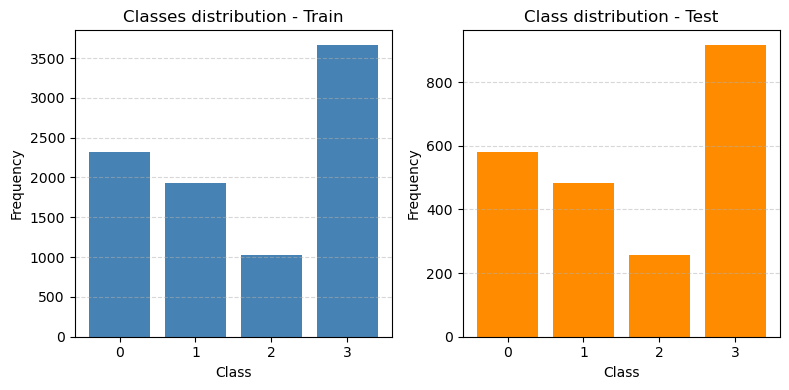

Train counts: [2324 1936 1029 3665]
Test counts : [581 484 257 917]


In [21]:
# Count the classes
train_counts = np.bincount(y_trainval)
test_counts  = np.bincount(y_test)

classes = np.arange(len(train_counts))

plt.figure(figsize=(8,4))

# Train
plt.subplot(1,2,1)
plt.bar(classes, train_counts, color='steelblue')
plt.title("Classes distribution - Train")
plt.xlabel("Class")
plt.ylabel("Frequency")
plt.xticks(classes)
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Test
plt.subplot(1,2,2)
plt.bar(classes, test_counts, color='darkorange')
plt.title("Class distribution - Test")
plt.xlabel("Class")
plt.ylabel("Frequency")
plt.xticks(classes)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

print("Train counts:", train_counts)
print("Test counts :", test_counts)

In [22]:
class BrainGATBranch(nn.Module):
    def __init__(self, in_channels, hidden_channels, dropout=0.5, num_layers=2, heads=2):

        if num_layers > 2:
            print('NUMBER OF LAYERS WRONG. Please select 1 or 2.')
            raise ValueError

        super().__init__()

        self.num_layers = num_layers

        # Convolutional layers
        self.conv1 = GATConv(in_channels, hidden_channels, heads=heads, dropout=dropout)
        self.bn1   = BatchNorm(hidden_channels*heads)

        if num_layers==2:
            self.conv2 = GATConv(hidden_channels*heads, hidden_channels*2, heads=1, concat=False, dropout=dropout)
            self.bn2   = BatchNorm(hidden_channels*2*1)
            
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, edge_index, batch):
        x = self.conv1(x, edge_index)
        x = self.bn1(x) 
        x = F.relu(x)
        x = self.dropout(x)
  
        if self.num_layers==2:
            x = self.conv2(x, edge_index)
            x = self.bn2(x)
            x = F.relu(x)
            x = self.dropout(x)

        x = global_mean_pool(x, batch)   # embedding of the graph
        return self.dropout(x)


class DualHemisphereGNN(nn.Module):
    def __init__(self, in_channels, hidden_channels, num_classes, dropout=0.5, num_layers=2, heads=2):
        super().__init__()
        # Two separate branches
        self.gcn_RH = BrainGATBranch(in_channels, hidden_channels, dropout, num_layers, heads=heads)     # each of these two blocks (LH and RH) duplicates hidden_channels
        self.gcn_LH = BrainGATBranch(in_channels, hidden_channels, dropout, num_layers, heads=heads)

        # Final classifier
        if num_layers == 1: 
            emb_dim = hidden_channels * heads * 2 
        else:
            emb_dim = (hidden_channels * 2) * 2

        self.fc = nn.Sequential(nn.Linear(emb_dim, hidden_channels), 
                                nn.ReLU(), nn.Dropout(dropout), 
                                nn.Linear(hidden_channels, num_classes))

    def forward(self, x_RH, edge_index_RH, batch_RH,
                      x_LH, edge_index_LH, batch_LH):
        emb_RH = self.gcn_RH(x_RH, edge_index_RH, batch_RH)
        emb_LH = self.gcn_LH(x_LH, edge_index_LH, batch_LH)

        # COncatenation
        emb = torch.cat([emb_RH, emb_LH], dim=1)

        return self.fc(emb)

In [ ]:
def create_graphs(num_nodes, X_seq_rh, X_seq_lh, labels_numeric,
                  normalization=None, mean=None, std=None,
                  min_val=None, max_val=None):

    # Compute normalization statistics
    if normalization in ['z', 'z_score']:

        # Concatenate RH and LH to compute shared statistics
        X_all = np.concatenate([X_seq_rh, X_seq_lh], axis=0)
        n_trials, seq_len, n_voxels = X_all.shape
        X_flat = X_all.reshape(-1, n_voxels)

        # Compute statistics only if not provided (training)
        if mean is None or std is None:
            mean = X_flat.mean(axis=0)
            std  = X_flat.std(axis=0) + 1e-8

        # Apply normalization
        X_seq_rh = (X_seq_rh - mean) / std
        X_seq_lh = (X_seq_lh - mean) / std


    elif normalization in ['minmax', 'min_max']:

        # Concatenate RH and LH to compute shared statistics
        X_all = np.concatenate([X_seq_rh, X_seq_lh], axis=0)
        n_trials, seq_len, n_voxels = X_all.shape
        X_flat = X_all.reshape(-1, n_voxels)

        # Compute stats 
        if min_val is None or max_val is None:
            min_val = X_flat.min(axis=0)
            max_val = X_flat.max(axis=0)
            max_val = np.where(max_val == min_val, max_val + 1e-8, max_val)

        # Apply normalization
        X_seq_rh = (X_seq_rh - min_val) / (max_val - min_val)
        X_seq_lh = (X_seq_lh - min_val) / (max_val - min_val)


    # Build fully connected undirected graph
    edges = list(itertools.combinations(range(num_nodes), 2))
    edges = edges + [(j, i) for (i, j) in edges]
    edge_index = torch.tensor(edges, dtype=torch.long).t().contiguous()


    # Build graph objects
    graphs_rh = []
    graphs_lh = []

    for i in range(len(labels_numeric)):
        y = torch.tensor(labels_numeric[i], dtype=torch.long)

        x_rh = torch.tensor(X_seq_rh[i], dtype=torch.float32)
        x_lh = torch.tensor(X_seq_lh[i], dtype=torch.float32)

        graphs_rh.append(Data(x=x_rh, edge_index=edge_index, y=y))
        graphs_lh.append(Data(x=x_lh, edge_index=edge_index, y=y))

    return graphs_rh, graphs_lh, mean, std, min_val, max_val

##### Grid Search

The next cells will implement a grid search to find the optimal parameters.

In [24]:
grid_params = {
    'normalization': ['z_score', 'min_max'],
    'hidden_channels': [8, 16],
    'batch_size': [32, 64],
    'optimizer': [torch.optim.Adam, torch.optim.SGD],
    'lr': [0.001, 0.0001],
    'num_layers': [1, 2]
}

from sklearn.model_selection import ParameterGrid
print(f'Number of combinations: {len(ParameterGrid(grid_params))}')

Number of combinations: 64


In [25]:
def train_grid_search(grid_params, n_epochs, num_nodes, X_seq_rh, X_seq_lh, labels_numeric, device):

    # Since the class are unbalanced I will chose the best model as the one with the highest F1 score (macro)
    best_params = None
    best_val_f1 = 0
    best_val_acc = 0
    
    for i, params in enumerate(ParameterGrid(grid_params)):

        print(f'Combination {i+1}/{len(ParameterGrid(grid_params))} - Params: {params}')
        
        X_rh_train, X_rh_val, X_lh_train, X_lh_val, y_train, y_val = train_test_split(X_seq_rh, X_seq_lh, 
                                                                    labels_numeric, test_size=0.3, stratify=labels_numeric, random_state=None) 
        
        #create graphs for train and val
        train_graphs_rh, train_graphs_lh, mean, std, min_val, max_val = create_graphs(num_nodes, X_rh_train, X_lh_train, 
                                        y_train, normalization=params['normalization']) 
        val_graphs_rh, val_graphs_lh, _, _, _, _ = create_graphs(num_nodes, X_rh_val, X_lh_val, 
                                        y_val, normalization=params['normalization'], 
                                        mean=mean, std=std, min_val=min_val, max_val=max_val) 

        # Create a pair so that when I call the batch in the train function, the LH and RH batches correspond
        train_pairs = list(zip(train_graphs_rh, train_graphs_lh))
        val_pairs   = list(zip(val_graphs_rh, val_graphs_lh))

        train_loader = DataLoader(train_pairs, batch_size=params['batch_size'], shuffle=True)
        val_loader   = DataLoader(val_pairs, batch_size=params['batch_size'])

        classes, counts = np.unique(y_train, return_counts=True) 
        class_weights = 1.0 / counts
        class_weights = class_weights / class_weights.sum() * len(classes) 
        class_weights_t = torch.tensor(class_weights, dtype=torch.float32).to(device)

        # Model, optimizer, criterion and scheduler
        model = DualHemisphereGNN(in_channels=51, hidden_channels=params['hidden_channels'], num_classes=4, dropout=0.5, num_layers=params['num_layers']).to(device)
        criterion = nn.CrossEntropyLoss(weight=class_weights_t.to(device))
        optimizer = params['optimizer'](model.parameters(), lr=params['lr'])
        scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.8, patience=8)


        for epoch in range(1, n_epochs+1):
            # Training loop
            model.train()
            train_preds, train_labels = [], []
            train_loss = 0.0

            for batch in train_loader:
                
                batch_RH, batch_LH = batch
                batch_RH, batch_LH = batch_RH.to(device), batch_LH.to(device)

                optimizer.zero_grad()

                out = model(batch_RH.x, batch_RH.edge_index, batch_RH.batch,
                            batch_LH.x, batch_LH.edge_index, batch_LH.batch)

                assert torch.equal(batch_RH.y, batch_LH.y)

                loss = criterion(out, batch_RH.y)  # the labels are the same. batch_RH.y == batch_LH.y
                loss.backward()
                optimizer.step()

                train_loss+=loss.item()
                train_preds.extend(out.argmax(dim=1).cpu().numpy())
                train_labels.extend(batch_RH.y.cpu().numpy())

            train_acc = accuracy_score(train_labels, train_preds)
            train_prec = precision_score(train_labels, train_preds, average="macro", zero_division=0)
            train_rec = recall_score(train_labels, train_preds, average="macro", zero_division=0)
            train_f1 = f1_score(train_labels, train_preds, average="macro", zero_division=0)

            # Validation loop
            model.eval()
            val_preds, val_labels = [], []
            val_loss = 0.0
            with torch.no_grad():
                for batch in val_loader:
                
                    batch_RH, batch_LH = batch
                    batch_RH, batch_LH = batch_RH.to(device), batch_LH.to(device)

                    out = model(batch_RH.x, batch_RH.edge_index, batch_RH.batch,
                            batch_LH.x, batch_LH.edge_index, batch_LH.batch)

                    assert torch.equal(batch_RH.y, batch_LH.y)

                    loss = criterion(out, batch_RH.y)  # the labels are the same. batch_RH.y == batch_LH.y

                    val_loss+=loss.item()
                    val_preds.extend(out.argmax(dim=1).cpu().numpy())
                    val_labels.extend(batch_RH.y.cpu().numpy())

            val_acc = accuracy_score(val_labels, val_preds)
            val_prec = precision_score(val_labels, val_preds, average="macro", zero_division=0)
            val_rec = recall_score(val_labels, val_preds, average="macro", zero_division=0)
            val_f1 = f1_score(val_labels, val_preds, average="macro", zero_division=0)

            # Scheduler step
            scheduler.step(val_loss)

            # Save the best one
            if val_f1 > best_val_f1:
                best_val_f1 = val_f1
                best_params = params
                best_val_acc = val_acc

            # Print metrics
            print(f"Epoch {epoch:3d}/{n_epochs:<3d}       Train Loss: {train_loss:9.4f}  -  Train Acc: {train_acc:6.3f}  -  Train F1: {train_f1:6.3f} \
            Val Loss: {val_loss:9.4f}  -  Val Acc: {val_acc:6.3f}  -  Val F1: {val_f1:6.3f}")
        
        print('\n')

    return best_params, best_val_f1, best_val_acc        

The best model parameters are chosen with the validation F1 MACRO.

Since the classes are unbalanced, accuracy is not an optimal metric.
Macro F1 calculates the F1-score for each class separately, then computes the arithmetic mean of the F1-scores of all classes.

For a single class, F1 is the harmonic mean of precision and recall.

Precision = how many samples predicted as class \(c\) are truly of class \(c\).

Recall = how many of the true samples of class \(c\) have been found by the model.

Consider four classes: \(C_1, C_2, C_3, C_4\).

1. For each class \(C_i\), compute:

$$
\text{Precision}_i = \frac{TP_i}{TP_i + FP_i}, \qquad
\text{Recall}_i = \frac{TP_i}{TP_i + FN_i}
$$

2. Compute the F1-score for each class:

$$
F1_i = 2 \cdot \frac{\text{Precision}_i \cdot \text{Recall}_i}{\text{Precision}_i + \text{Recall}_i}
$$

3. The F1-macro score is the arithmetic mean of the four class-wise F1-scores:

$$
F1_{\text{macro}} = \frac{1}{4} \left( F1_1 + F1_2 + F1_3 + F1_4 \right)
$$

In [26]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f'Device: {device}')

if True:   
    if not os.path.exists(os.path.join(variables.BOLD5000_PATH, 'best_params_multi_branch_gnn.txt')):
        best_params, best_val_f1, best_val_acc = train_grid_search(grid_params, n_epochs=30, num_nodes=5, X_seq_rh=X_rh_train, X_seq_lh=X_lh_train, 
                                                                    labels_numeric=y_trainval, device=device)

        # Cannot save in json file a class "optim", convert everything to string
        best_params_string = {}
        for key in best_params.keys():
            best_params_string[key] = str(best_params[key])

        # Save the best params in string format
        with open(os.path.join(variables.BOLD5000_PATH, 'best_params_multi_branch_gnn.txt'), 'w') as file:
            json.dump(best_params_string, file)

    else: # Load best params 
        with open(os.path.join(variables.BOLD5000_PATH, 'best_params_multi_branch_gnn.txt'), 'r') as file:
            best_params_string = json.load(file)

        # from strings to original type
        best_params = {}
        for i in best_params_string.keys():
            if i == 'lr':
                best_params[i] = float(best_params_string[i])
            elif i == 'batch_size' or i == 'hidden_channels' or i == 'num_layers':
                best_params[i] = int(best_params_string[i])
            elif i == 'optimizer':
                # Extract "Adam" or "SGD"
                class_name = best_params_string[i].split(".")[-1].replace("'>","")
                best_params[i] = getattr(optim, class_name)
            else:
                best_params[i] = best_params_string[i]

        print(f'Best params: {best_params}')

Device: cuda
Best params: {'batch_size': 32, 'hidden_channels': 16, 'lr': 0.001, 'normalization': 'z_score', 'num_layers': 2, 'optimizer': <class 'torch.optim.adam.Adam'>}


##### Train best model with no augmentation and cross entropy loss

In [31]:
def train_best_gnn(n_epochs, best_params, X_seq_rh, X_seq_lh, labels_numeric, num_nodes=5, device="cuda"):

    print(f' -  Params: {best_params}')

    X_rh_train, X_rh_val, X_lh_train, X_lh_val, y_train, y_val = train_test_split(X_seq_rh, X_seq_lh, 
                                                                    labels_numeric, test_size=0.3, stratify=labels_numeric, random_state=42) 
        
    #create graphs for train and val
    train_graphs_rh, train_graphs_lh, mean, std, min_val, max_val = create_graphs(num_nodes, X_rh_train, X_lh_train, 
                                        y_train, normalization=best_params['normalization']) 
    val_graphs_rh, val_graphs_lh, _, _, _, _ = create_graphs(num_nodes, X_rh_val, X_lh_val, 
                                        y_val, normalization=best_params['normalization'], 
                                        mean=mean, std=std, min_val=min_val, max_val=max_val) 

    # Create a pair so that when I call the batch in the train function, the LH and RH batches correspond
    train_pairs = list(zip(train_graphs_rh, train_graphs_lh))
    val_pairs   = list(zip(val_graphs_rh, val_graphs_lh))

    assert len(train_graphs_rh) == len(train_graphs_lh)
    print(f'Len train set: {len(train_graphs_rh)} - Len val set: {len(val_graphs_rh)}')

    train_loader = DataLoader(train_pairs, batch_size=best_params['batch_size'], shuffle=True)
    val_loader   = DataLoader(val_pairs, batch_size=best_params['batch_size'])

    classes, counts = np.unique(y_train, return_counts=True)
    class_weights = 1.0 / counts
    class_weights = class_weights / class_weights.sum() * len(classes)
    class_weights_t = torch.tensor(class_weights, dtype=torch.float32).to(device)


    # Model
    model = DualHemisphereGNN(
        in_channels=51,
        hidden_channels=best_params['hidden_channels'],
        num_classes=4,
        dropout=0.5,
        num_layers=best_params['num_layers']
    ).to(device)

    criterion = nn.CrossEntropyLoss(weight=class_weights_t.to(device))
    optimizer = best_params['optimizer'](model.parameters(), lr=best_params['lr'], weight_decay=1e-4)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

    # Tracking
    train_losses, train_accs, train_f1s = [], [], []
    val_losses, val_accs, val_f1s = [], [], []

    # Best model tracking
    best_val_f1 = 0.0
    best_epoch = 0
    best_model_path = "/workspace/devcontainer-bigdata/models/best_model_multi_branch_gnn.pt"

    for epoch in range(1, n_epochs + 1):

        #training loop
        model.train()
        train_preds, train_labels = [], []
        train_loss = 0.0

        for batch in train_loader:
            batch_RH, batch_LH = batch
            batch_RH, batch_LH = batch_RH.to(device), batch_LH.to(device)

            optimizer.zero_grad()

            out = model(batch_RH.x, batch_RH.edge_index, batch_RH.batch,
                        batch_LH.x, batch_LH.edge_index, batch_LH.batch)

            assert torch.equal(batch_RH.y, batch_LH.y)

            loss = criterion(out, batch_RH.y)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            train_preds.extend(out.argmax(dim=1).cpu().numpy())
            train_labels.extend(batch_RH.y.cpu().numpy())

        train_acc = accuracy_score(train_labels, train_preds)
        train_f1 = f1_score(train_labels, train_preds, average="macro", zero_division=0)

        train_losses.append(train_loss)
        train_accs.append(train_acc)
        train_f1s.append(train_f1)

        # validation
        model.eval()
        val_preds, val_labels = [], []
        val_loss = 0.0

        with torch.no_grad():
            for batch in val_loader:
                batch_RH, batch_LH = batch
                batch_RH, batch_LH = batch_RH.to(device), batch_LH.to(device)

                out = model(batch_RH.x, batch_RH.edge_index, batch_RH.batch,
                            batch_LH.x, batch_LH.edge_index, batch_LH.batch)

                loss = criterion(out, batch_RH.y)
                val_loss += loss.item()

                val_preds.extend(out.argmax(dim=1).cpu().numpy())
                val_labels.extend(batch_RH.y.cpu().numpy())

        val_acc = accuracy_score(val_labels, val_preds)
        val_f1 = f1_score(val_labels, val_preds, average="macro", zero_division=0)

        val_losses.append(val_loss)
        val_accs.append(val_acc)
        val_f1s.append(val_f1)

        # save best model
        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            best_epoch = epoch
            torch.save(model.state_dict(), best_model_path)
            print(f"-- New best model saved at epoch {epoch} with F1 = {val_f1:.4f}")

        scheduler.step(val_loss)

        print(f"Epoch {epoch:3d}/{n_epochs:<3d} | "
              f"Train Loss: {train_loss:8.3f} | Train F1: {train_f1:5.3f} | "
              f"Val Loss: {val_loss:8.3f} | Val F1: {val_f1:5.3f}")


    print("\nTraining completed.\n")

    # -plot
    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    axes = axes.flatten()

    axes[0].plot(train_losses, label='Train Loss', color='green')
    axes[0].plot(val_losses, label='Val Loss', color='blue')
    axes[0].set_title("Loss")
    axes[0].legend()
    axes[0].grid(True, linestyle='--', alpha=0.6)

    axes[1].plot(train_f1s, label='Train F1', color='green')
    axes[1].plot(val_f1s, label='Val F1', color='blue')
    axes[1].set_title("F1 Score")
    axes[1].legend()
    axes[1].grid(True, linestyle='--', alpha=0.6)

    axes[2].plot(train_accs, label='Train Acc', color='green')
    axes[2].plot(val_accs, label='Val Acc', color='blue')
    axes[2].set_title("Accuracy")
    axes[2].legend()
    axes[2].grid(True, linestyle='--', alpha=0.6)

    plt.show()

    return model


 -  Params: {'batch_size': 32, 'hidden_channels': 16, 'lr': 0.001, 'normalization': 'z_score', 'num_layers': 2, 'optimizer': <class 'torch.optim.adam.Adam'>}
Len train set: 6267 - Len val set: 2687
-- New best model saved at epoch 1 with F1 = 0.1303
Epoch   1/150 | Train Loss:  275.385 | Train F1: 0.210 | Val Loss:  116.571 | Val F1: 0.130
-- New best model saved at epoch 2 with F1 = 0.1681
Epoch   2/150 | Train Loss:  272.238 | Train F1: 0.234 | Val Loss:  116.435 | Val F1: 0.168
-- New best model saved at epoch 3 with F1 = 0.2212
Epoch   3/150 | Train Loss:  271.750 | Train F1: 0.244 | Val Loss:  116.277 | Val F1: 0.221
Epoch   4/150 | Train Loss:  271.549 | Train F1: 0.259 | Val Loss:  116.100 | Val F1: 0.203
Epoch   5/150 | Train Loss:  270.281 | Train F1: 0.277 | Val Loss:  115.824 | Val F1: 0.209
Epoch   6/150 | Train Loss:  269.579 | Train F1: 0.282 | Val Loss:  115.421 | Val F1: 0.219
-- New best model saved at epoch 7 with F1 = 0.3001
Epoch   7/150 | Train Loss:  266.902 | Tra

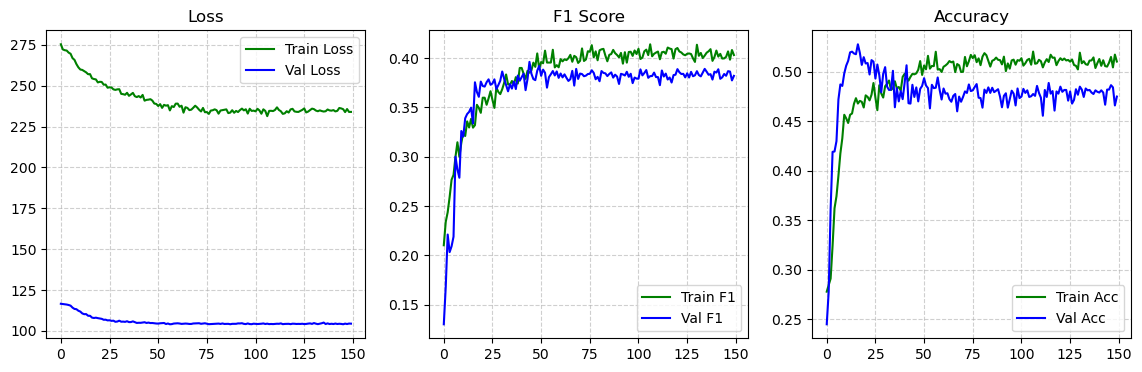

DualHemisphereGNN(
  (gcn_RH): BrainGATBranch(
    (conv1): GATConv(51, 16, heads=2)
    (bn1): BatchNorm(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (conv2): GATConv(32, 32, heads=1)
    (bn2): BatchNorm(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (dropout): Dropout(p=0.5, inplace=False)
  )
  (gcn_LH): BrainGATBranch(
    (conv1): GATConv(51, 16, heads=2)
    (bn1): BatchNorm(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (conv2): GATConv(32, 32, heads=1)
    (bn2): BatchNorm(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (dropout): Dropout(p=0.5, inplace=False)
  )
  (fc): Sequential(
    (0): Linear(in_features=64, out_features=16, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.5, inplace=False)
    (3): Linear(in_features=16, out_features=4, bias=True)
  )
)

In [32]:
device = "cuda" if torch.cuda.is_available() else "cpu"
train_best_gnn(n_epochs=150, best_params=best_params, X_seq_rh=X_rh_train, X_seq_lh=X_lh_train, 
               labels_numeric = y_trainval, num_nodes = 5, device = device)

##### Train best model with data augmentation on the fly and cross entropy loss

Trying with data augmentation for graphs:
- Edge Dropout (Random Edge Removing): helps the model not to depend excessively to specific connections.
- Node Feature Masking (put some nodes' features at 0): similar to the dropout on the features.
- Feature Noise Injection: adds gaussian noise to the nodes features

Data augmentation must be applied only to training data.

In [27]:
def augment_graph(graph, edge_drop=0.4, feature_mask=0.3, noise_std=0.02):
    
    graph = graph.clone() 
    
    # 1. Edge dropout 
    graph.edge_index, _ = dropout_edge(graph.edge_index, p=edge_drop) 
    
    # 2. Feature masking 
    if feature_mask > 0: 
        mask = torch.rand(graph.x.shape) > feature_mask 
        graph.x = graph.x * mask 
    
    # 3. Gaussian noise 
    if noise_std > 0: 
        graph.x = graph.x + noise_std * torch.randn_like(graph.x)
    
    return graph

In [34]:
def train_best_gnn_augmentation_on_the_fly(n_epochs, best_params, X_seq_rh, X_seq_lh, labels_numeric, augment_graph, num_nodes = 5, device= "cuda"):
   
    if True:

        print(f' -  Params: {best_params}')

        X_rh_train, X_rh_val, X_lh_train, X_lh_val, y_train, y_val = train_test_split(X_seq_rh, X_seq_lh, 
                                                                    labels_numeric, test_size=0.3, stratify=labels_numeric, random_state=42) 
        
        #create graphs for train and val
        train_graphs_rh, train_graphs_lh, mean, std, min_val, max_val = create_graphs(num_nodes, X_rh_train, X_lh_train, 
                                        y_train, normalization=best_params['normalization']) 
        val_graphs_rh, val_graphs_lh, _, _, _, _ = create_graphs(num_nodes, X_rh_val, X_lh_val, 
                                        y_val, normalization=best_params['normalization'], 
                                        mean=mean, std=std, min_val=min_val, max_val=max_val) 
    
        
        # print dimensions
        assert len(train_graphs_rh)==len(train_graphs_lh)
        print(f'Len train set: {len(train_graphs_rh)} - Len val set: {len(val_graphs_rh)}')

        # Create a pair so that when I call the batch in the train function, the LH and RH batches correspond
        train_pairs = list(zip(train_graphs_rh, train_graphs_lh))
        val_pairs   = list(zip(val_graphs_rh, val_graphs_lh))

        train_loader = DataLoader(train_pairs, batch_size=best_params['batch_size'], shuffle=True)
        val_loader   = DataLoader(val_pairs, batch_size=best_params['batch_size'])

        classes, counts = np.unique(y_train, return_counts=True) 
        class_weights = 1.0 / counts
        class_weights = class_weights / class_weights.sum() * len(classes) 
        class_weights_t = torch.tensor(class_weights, dtype=torch.float32).to(device)

        # Model, optimizer, criterion and scheduler
        model = DualHemisphereGNN(in_channels=51, hidden_channels=best_params['hidden_channels'], num_classes=4, dropout=0.5, num_layers=best_params['num_layers']).to(device)
        criterion = nn.CrossEntropyLoss(weight=class_weights_t.to(device))
        optimizer = best_params['optimizer'](model.parameters(), lr=best_params['lr'], weight_decay=1e-4)
        scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

        train_losses, train_accs, train_f1s, val_losses, val_accs, val_f1s = [], [], [], [], [], []

        # For restoring best weights
        best_val_f1 = 0.0
        best_model_state = None
        best_epoch = 0

        for epoch in range(1, n_epochs+1):
            # Training loop
            model.train()
            train_preds, train_labels = [], []
            train_loss = 0.0

            for b_idx, batch in enumerate(train_loader):
                
                batch_RH, batch_LH = batch

                # AUGMENTATION ON THE FLY
                batch_RH = augment_graph(batch_RH)
                batch_LH = augment_graph(batch_LH)

                batch_RH, batch_LH = batch_RH.to(device), batch_LH.to(device)

                #print(f"[Epoch {epoch} | Batch {b_idx}] RH edges: {batch_RH.edge_index.size(1)}")

                optimizer.zero_grad()

                out = model(batch_RH.x, batch_RH.edge_index, batch_RH.batch,
                            batch_LH.x, batch_LH.edge_index, batch_LH.batch)

                assert torch.equal(batch_RH.y, batch_LH.y)

                loss = criterion(out, batch_RH.y)  # the labels are the same. batch_RH.y == batch_LH.y
                loss.backward()
                optimizer.step()

                train_loss+=loss.item()
                train_preds.extend(out.argmax(dim=1).cpu().numpy())
                train_labels.extend(batch_RH.y.cpu().numpy())

            train_acc = accuracy_score(train_labels, train_preds)
            train_prec = precision_score(train_labels, train_preds, average="macro", zero_division=0)
            train_rec = recall_score(train_labels, train_preds, average="macro", zero_division=0)
            train_f1 = f1_score(train_labels, train_preds, average="macro", zero_division=0)

            train_accs.append(train_acc)
            train_losses.append(train_loss)
            train_f1s.append(train_f1)

            # Validation loop
            model.eval()
            val_preds, val_labels = [], []
            val_loss = 0.0
            with torch.no_grad():
                for batch in val_loader:
                
                    batch_RH, batch_LH = batch
                    batch_RH, batch_LH = batch_RH.to(device), batch_LH.to(device)

                    out = model(batch_RH.x, batch_RH.edge_index, batch_RH.batch,
                            batch_LH.x, batch_LH.edge_index, batch_LH.batch)

                    assert torch.equal(batch_RH.y, batch_LH.y)

                    loss = criterion(out, batch_RH.y)  # the labels are the same. batch_RH.y == batch_LH.y

                    val_loss+=loss.item()
                    val_preds.extend(out.argmax(dim=1).cpu().numpy())
                    val_labels.extend(batch_RH.y.cpu().numpy())

            val_acc = accuracy_score(val_labels, val_preds)
            val_prec = precision_score(val_labels, val_preds, average="macro", zero_division=0)
            val_rec = recall_score(val_labels, val_preds, average="macro", zero_division=0)
            val_f1 = f1_score(val_labels, val_preds, average="macro", zero_division=0)

            val_accs.append(val_acc)
            val_losses.append(val_loss)
            val_f1s.append(val_f1)

            # For restoring best weights
            if val_f1 > best_val_f1:
                best_val_f1 = val_f1
                best_model_state = model.state_dict()
                best_epoch = epoch

            # Scheduler step
            scheduler.step(val_loss)

            # Print metrics
            print(f"Epoch {epoch:3d}/{n_epochs:<3d}       Train Loss: {train_loss:9.4f}  -  Train Acc: {train_acc:6.3f}  -  Train F1: {train_f1:6.3f} \
            Val Loss: {val_loss:9.4f}  -  Val Acc: {val_acc:6.3f}  -  Val F1: {val_f1:6.3f}")
        
        # At the end of the training, restore the best weights
        if best_model_state is not None:
            model.load_state_dict(best_model_state)
            print(f"Restored best model with F1 = {best_val_f1:.4f} at epoch {best_epoch}")

        torch.save(model.state_dict(), "/workspace/devcontainer-bigdata/models/best_model_multi_branch_gnn_aug_onthefly.pt")
        
        print('\n')

        # Plots
        fig, axes = plt.subplots(1,3, figsize=(14,4))
        axes = axes.flatten()
        # Losses
        axes[0].plot(range(1, len(train_losses)+1), train_losses, label='Training Loss', color='forestgreen')
        axes[0].plot(range(1, len(train_losses)+1), val_losses, label='Validation Loss', color='navy')
        axes[0].set_title("Loss")
        axes[0].set_xlabel("Epoch")
        axes[0].legend()
        axes[0].grid(True, linestyle='--', alpha=0.6)

        # F1 scores
        axes[1].plot(range(1, len(train_losses)+1), train_f1s, label='Training F1', color='forestgreen')
        axes[1].plot(range(1, len(train_losses)+1), val_f1s, label='Validation F1', color='navy')
        axes[1].set_title("F1 Score")
        axes[1].set_xlabel("Epoch")
        axes[1].legend()
        axes[1].grid(True, linestyle='--', alpha=0.6)

        # Accuracies
        axes[2].plot(range(1, len(train_losses)+1), train_accs, label='Training Acc', color='forestgreen')
        axes[2].plot(range(1, len(train_losses)+1), val_accs, label='Validation Acc', color='navy')
        axes[2].set_title("Accuracy")
        axes[2].set_xlabel("Epoch")
        axes[2].legend()
        axes[2].grid(True, linestyle='--', alpha=0.6)     

        fig.suptitle('Training best model with augmentation on the fly', fontsize=9, y=0.99) 

 -  Params: {'batch_size': 32, 'hidden_channels': 16, 'lr': 0.001, 'normalization': 'z_score', 'num_layers': 2, 'optimizer': <class 'torch.optim.adam.Adam'>}
Len train set: 6267 - Len val set: 2687
Epoch   1/150       Train Loss:  274.2480  -  Train Acc:  0.268  -  Train F1:  0.247             Val Loss:  116.3277  -  Val Acc:  0.265  -  Val F1:  0.144
Epoch   2/150       Train Loss:  272.4854  -  Train Acc:  0.276  -  Train F1:  0.228             Val Loss:  116.3144  -  Val Acc:  0.267  -  Val F1:  0.144
Epoch   3/150       Train Loss:  272.2353  -  Train Acc:  0.263  -  Train F1:  0.220             Val Loss:  116.2898  -  Val Acc:  0.277  -  Val F1:  0.150
Epoch   4/150       Train Loss:  271.2397  -  Train Acc:  0.303  -  Train F1:  0.248             Val Loss:  115.9601  -  Val Acc:  0.389  -  Val F1:  0.235
Epoch   5/150       Train Loss:  271.6268  -  Train Acc:  0.315  -  Train F1:  0.240             Val Loss:  115.8079  -  Val Acc:  0.392  -  Val F1:  0.236
Epoch   6/150       Tr

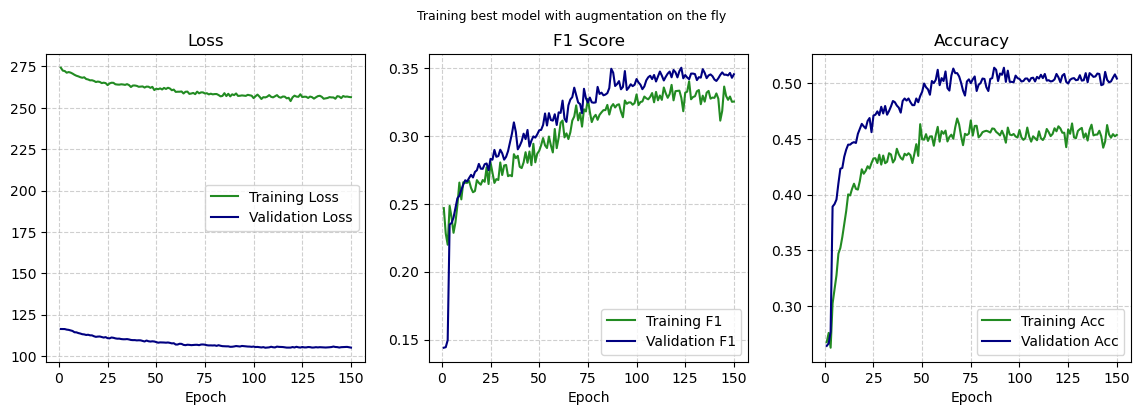

In [35]:
device = "cuda" if torch.cuda.is_available() else "cpu"
train_best_gnn_augmentation_on_the_fly(n_epochs=150, best_params=best_params, X_seq_rh=X_rh_train, X_seq_lh=X_lh_train, 
                                 labels_numeric=y_trainval, augment_graph=augment_graph, num_nodes=5, device=device)

##### Visualize augmentations

In [39]:
def plot_graph_stylized(graph, ax, title=""):
    '''
    Args:
        graph: object of type torch_geometric.data.Data
        ax: object matplotlib on which to draw
        title: optional string for the title of the figure
    '''

    G = nx.Graph()      # Create an empty graph called G

    # Add nodes with a color based on mean feature value
    # graph.x is the matrix of the nodes features, shape (N, F).
    # N = number of nodes
    # F = features number for each node
    # graph.x.size(0) is the number of nodes
    for i in range(graph.x.size(0)):                    # for each node
        G.add_node(i, value=float(graph.x[i].mean()))   # compute the mean of the features of that node
                                                        # adds a node to G, and assigns to it a value based on the mean
    # Add edges
    edges = graph.edge_index.t().cpu().numpy()
    for u, v in edges:
        G.add_edge(int(u), int(v))

    # Node colors = mean feature value
    node_colors = [G.nodes[n]["value"] for n in G.nodes()]

    # Create a dict
    labels = {i: RH_order[i] for i in range(len(RH_order))}

    # Calculates the 2d positions of the nodes for the figure
    # pos is a dictionary, like node_0: [x0, y0]    - node_1: [x1, y1] ...
    pos = nx.spring_layout(G, seed=42)

    # G is the graph to plot
    nx.draw(
        G,
        pos=pos,
        with_labels=True,
        labels=labels,
        node_color=node_colors,
        cmap="viridis",
        node_size=600,
        font_size=8,
        edge_color="gray",
        ax=ax
    )
    ax.set_title(title)
    ax.axis("off")

Some graphs don't have all the connections because of "edge gropout".
The "structure" change is just a visual effect.

The next cell will select one sample graph, to be plot, to show if the augmentation on the fly is working or not.

In [40]:
# Sample
train_samples_rh, train_samples_lh, mean, std, min_val, max_val = create_graphs(5, X_rh_train, X_lh_train, 
                                        y_trainval, normalization=best_params['normalization']) 

In [41]:
sample = train_samples_rh[0]

In [ ]:
def visualize_augmentation_grid_with_features(graph, augment_graph, n_epochs=5):
    '''
    Args:
        graph: a graph (object torch_geometric.data.Data)
        augment_graph: a function with graph augmentation
        n_epochs: number of changes to show
    It plots two columns showing the changes in the graph structure, and the changes in the features of each node, due to augmentations.
        '''
    cols = 2
    rows = n_epochs+1

    fig, axes = plt.subplots(rows, cols, figsize=(cols*3, rows*3.4))
    axes = axes.flatten()

    original = graph.clone()

    ax_graph = axes[0] 
    plot_graph_stylized(original, ax_graph, title="Original Graph") 
    ax_feat = axes[1] 
    orig_vals = original.x.mean(dim=1).cpu().numpy() 
    nodes = range(len(orig_vals)) 
    ax_feat.plot(nodes, orig_vals, marker='o', color="blue") 
    ax_feat.set_xticks(nodes) 

    # Use RH order to assign names to the plotted nodes, instead of 0, 1, 2, 3, 4
    ax_feat.set_xticklabels(RH_order, rotation=30, fontsize=8)
    ax_feat.set_title("Original Features") 
    ax_feat.set_xlabel("Node") 
    ax_feat.set_ylabel("Mean feature") 
    ax_feat.grid(alpha=0.3)

    for i in range(n_epochs):
        augmented = augment_graph(original.clone())

        # Plot the graph (first column)
        ax_graph = axes[2*(i+1)]
        plot_graph_stylized(augmented, ax_graph, title=f"Epoch {i+1}")

        # Plot the features (second column)
        ax_feat = axes[2*(1+i) + 1]
        orig_vals = original.x.mean(dim=1).cpu().numpy()
        aug_vals  = augmented.x.mean(dim=1).cpu().numpy()

        nodes = range(len(orig_vals))
        ax_feat.plot(nodes, orig_vals, marker='o', label="Original", color="blue")
        ax_feat.plot(nodes, aug_vals, marker='o', label="Augmented", color="orange")
        ax_feat.set_xticks(nodes) 
        ax_feat.set_xticklabels(RH_order, rotation=30, fontsize=8)
        ax_feat.set_title(f"Features Epoch {i+1}")
        ax_feat.set_xlabel("Node")
        ax_feat.set_ylabel("Mean feature")
        ax_feat.grid(alpha=0.3)
        ax_feat.legend()

    plt.tight_layout()
    plt.show()

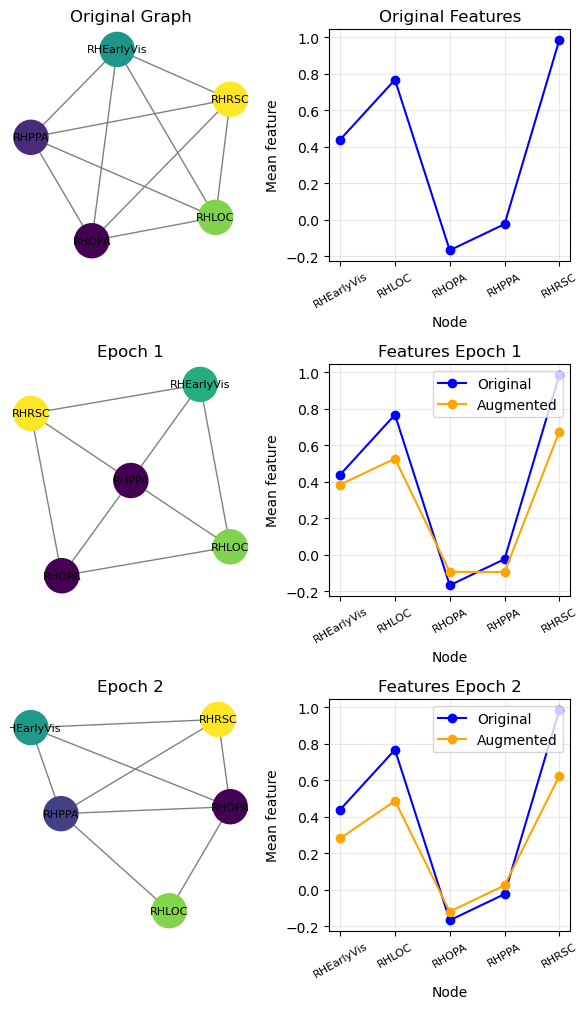

In [56]:
visualize_augmentation_grid_with_features(sample, augment_graph, n_epochs=2)

Each node in the graph is a feature vector (of length 51).

The plots in the right column show the mean of the features for each node.

Feature mask is an augmentation which brings to zero some random features. 
The noise is added to the features. Therefore, these two augmentations change the features of each node.

The plots in the left column show the effects of the "edge dropout" augmentation.

##### Train best model with data augmentation on the fly and focal loss

Trying to use focal loss to keep more into account the class imbalance.

In [46]:
import torch.nn.functional as F

def focal_loss(inputs, targets, alpha=1.0, gamma=2.0):
    """
    inputs: logits del modello (batch_size, num_classes)
    targets: etichette (batch_size)
    alpha: peso delle classi difficili
    gamma: focusing parameter
    """
    ce = F.cross_entropy(inputs, targets, reduction='none')
    pt = torch.exp(-ce)
    loss = alpha * (1 - pt)**gamma * ce
    return loss.mean()

In [47]:
def train_best_gnn_augmentation_on_the_fly_focalloss(n_epochs, best_params, X_seq_rh, X_seq_lh, labels_numeric, augment_graph, num_nodes = 5, device= "cuda"):
   
    if True:

        print(f' -  Params: {best_params}')

        X_rh_train, X_rh_val, X_lh_train, X_lh_val, y_train, y_val = train_test_split(X_seq_rh, X_seq_lh, 
                                                                    labels_numeric, test_size=0.3, stratify=labels_numeric, random_state=42) 
        
        #create graphs for train and val
        train_graphs_rh, train_graphs_lh, mean, std, min_val, max_val = create_graphs(num_nodes, X_rh_train, X_lh_train, 
                                        y_train, normalization=best_params['normalization']) 
        val_graphs_rh, val_graphs_lh, _, _, _, _ = create_graphs(num_nodes, X_rh_val, X_lh_val, 
                                        y_val, normalization=best_params['normalization'], 
                                        mean=mean, std=std, min_val=min_val, max_val=max_val) 
    
        
        # print dimensions
        assert len(train_graphs_rh)==len(train_graphs_lh)
        print(f'Len train set: {len(train_graphs_rh)} - Len val set: {len(val_graphs_rh)}')

        # Create a pair so that when I call the batch in the train function, the LH and RH batches correspond
        train_pairs = list(zip(train_graphs_rh, train_graphs_lh))
        val_pairs   = list(zip(val_graphs_rh, val_graphs_lh))

        train_loader = DataLoader(train_pairs, batch_size=best_params['batch_size'], shuffle=True)
        val_loader   = DataLoader(val_pairs, batch_size=best_params['batch_size'])

        classes, counts = np.unique(y_train, return_counts=True) 
        class_weights = 1.0 / counts
        class_weights = class_weights / class_weights.sum() * len(classes) 
        class_weights_t = torch.tensor(class_weights, dtype=torch.float32).to(device)

        # Model, optimizer, criterion and scheduler
        model = DualHemisphereGNN(in_channels=51, hidden_channels=best_params['hidden_channels'], num_classes=4, dropout=0.5, num_layers=best_params['num_layers']).to(device)
        criterion = lambda logits, labels: focal_loss(logits, labels, alpha=1.0, gamma=8.0)
        optimizer = best_params['optimizer'](model.parameters(), lr=best_params['lr'], weight_decay=1e-4)
        scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

        train_losses, train_accs, train_f1s, val_losses, val_accs, val_f1s = [], [], [], [], [], []

        # For restoring best weights
        best_val_f1 = 0.0
        best_model_state = None
        best_epoch = 0

        for epoch in range(1, n_epochs+1):
            # Training loop
            model.train()
            train_preds, train_labels = [], []
            train_loss = 0.0

            for b_idx, batch in enumerate(train_loader):
                
                batch_RH, batch_LH = batch

                # AUGMENTATION ON THE FLY
                batch_RH = augment_graph(batch_RH)
                batch_LH = augment_graph(batch_LH)

                batch_RH, batch_LH = batch_RH.to(device), batch_LH.to(device)

                #print(f"[Epoch {epoch} | Batch {b_idx}] RH edges: {batch_RH.edge_index.size(1)}")

                optimizer.zero_grad()

                out = model(batch_RH.x, batch_RH.edge_index, batch_RH.batch,
                            batch_LH.x, batch_LH.edge_index, batch_LH.batch)

                assert torch.equal(batch_RH.y, batch_LH.y)

                loss = criterion(out, batch_RH.y)  # the labels are the same. batch_RH.y == batch_LH.y
                loss.backward()
                optimizer.step()

                train_loss+=loss.item()
                train_preds.extend(out.argmax(dim=1).cpu().numpy())
                train_labels.extend(batch_RH.y.cpu().numpy())

            train_acc = accuracy_score(train_labels, train_preds)
            train_prec = precision_score(train_labels, train_preds, average="macro", zero_division=0)
            train_rec = recall_score(train_labels, train_preds, average="macro", zero_division=0)
            train_f1 = f1_score(train_labels, train_preds, average="macro", zero_division=0)

            train_accs.append(train_acc)
            train_losses.append(train_loss)
            train_f1s.append(train_f1)

            # Validation loop
            model.eval()
            val_preds, val_labels = [], []
            val_loss = 0.0
            with torch.no_grad():
                for batch in val_loader:
                
                    batch_RH, batch_LH = batch
                    batch_RH, batch_LH = batch_RH.to(device), batch_LH.to(device)

                    out = model(batch_RH.x, batch_RH.edge_index, batch_RH.batch,
                            batch_LH.x, batch_LH.edge_index, batch_LH.batch)

                    assert torch.equal(batch_RH.y, batch_LH.y)

                    loss = criterion(out, batch_RH.y)  # the labels are the same. batch_RH.y == batch_LH.y

                    val_loss+=loss.item()
                    val_preds.extend(out.argmax(dim=1).cpu().numpy())
                    val_labels.extend(batch_RH.y.cpu().numpy())

            val_acc = accuracy_score(val_labels, val_preds)
            val_prec = precision_score(val_labels, val_preds, average="macro", zero_division=0)
            val_rec = recall_score(val_labels, val_preds, average="macro", zero_division=0)
            val_f1 = f1_score(val_labels, val_preds, average="macro", zero_division=0)

            val_accs.append(val_acc)
            val_losses.append(val_loss)
            val_f1s.append(val_f1)

            # For restoring best weights
            if val_f1 > best_val_f1:
                best_val_f1 = val_f1
                best_model_state = model.state_dict()
                best_epoch = epoch

            # Scheduler step
            scheduler.step(val_loss)

            # Print metrics
            print(f"Epoch {epoch:3d}/{n_epochs:<3d}       Train Loss: {train_loss:9.4f}  -  Train Acc: {train_acc:6.3f}  -  Train F1: {train_f1:6.3f} \
            Val Loss: {val_loss:9.4f}  -  Val Acc: {val_acc:6.3f}  -  Val F1: {val_f1:6.3f}")
        
        # At the end of the training, restore the best weights
        if best_model_state is not None:
            model.load_state_dict(best_model_state)
            print(f"Restored best model with F1 = {best_val_f1:.4f} at epoch {best_epoch}")

        torch.save(model.state_dict(), "/workspace/devcontainer-bigdata/models/best_model_multi_branch_gnn_aug_onthefly_focalloss.pt")
        
        print('\n')

        # Plots
        fig, axes = plt.subplots(1,3, figsize=(14,4))
        axes = axes.flatten()
        # Losses
        axes[0].plot(range(1, len(train_losses)+1), train_losses, label='Training Loss', color='forestgreen')
        axes[0].plot(range(1, len(train_losses)+1), val_losses, label='Validation Loss', color='navy')
        axes[0].set_title("Loss")
        axes[0].set_xlabel("Epoch")
        axes[0].legend()
        axes[0].grid(True, linestyle='--', alpha=0.6)

        # F1 scores
        axes[1].plot(range(1, len(train_losses)+1), train_f1s, label='Training F1', color='forestgreen')
        axes[1].plot(range(1, len(train_losses)+1), val_f1s, label='Validation F1', color='navy')
        axes[1].set_title("F1 Score")
        axes[1].set_xlabel("Epoch")
        axes[1].legend()
        axes[1].grid(True, linestyle='--', alpha=0.6)

        # Accuracies
        axes[2].plot(range(1, len(train_losses)+1), train_accs, label='Training Acc', color='forestgreen')
        axes[2].plot(range(1, len(train_losses)+1), val_accs, label='Validation Acc', color='navy')
        axes[2].set_title("Accuracy")
        axes[2].set_xlabel("Epoch")
        axes[2].legend()
        axes[2].grid(True, linestyle='--', alpha=0.6)     

        fig.suptitle('Training best model with augmentation on the fly', fontsize=9, y=0.99) 

 -  Params: {'batch_size': 32, 'hidden_channels': 16, 'lr': 0.001, 'normalization': 'z_score', 'num_layers': 2, 'optimizer': <class 'torch.optim.adam.Adam'>}
Len train set: 6267 - Len val set: 2687
Epoch   1/150       Train Loss:   27.1422  -  Train Acc:  0.359  -  Train F1:  0.220             Val Loss:   10.6170  -  Val Acc:  0.410  -  Val F1:  0.147
Epoch   2/150       Train Loss:   24.8770  -  Train Acc:  0.406  -  Train F1:  0.174             Val Loss:   10.4990  -  Val Acc:  0.410  -  Val F1:  0.146
Epoch   3/150       Train Loss:   24.6195  -  Train Acc:  0.408  -  Train F1:  0.157             Val Loss:   10.4875  -  Val Acc:  0.409  -  Val F1:  0.145
Epoch   4/150       Train Loss:   24.6242  -  Train Acc:  0.408  -  Train F1:  0.150             Val Loss:   10.4790  -  Val Acc:  0.409  -  Val F1:  0.145
Epoch   5/150       Train Loss:   24.5255  -  Train Acc:  0.409  -  Train F1:  0.150             Val Loss:   10.4603  -  Val Acc:  0.409  -  Val F1:  0.145
Epoch   6/150       Tr

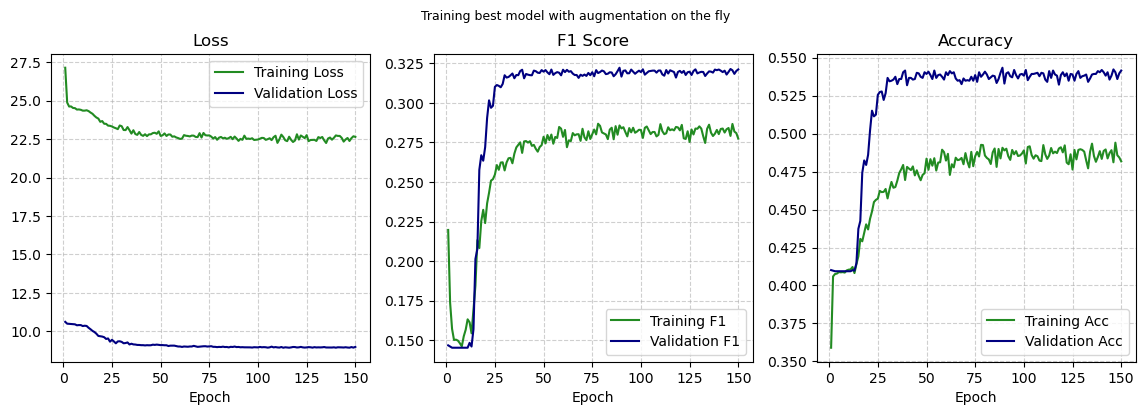

In [48]:
device = "cuda" if torch.cuda.is_available() else "cpu"
train_best_gnn_augmentation_on_the_fly_focalloss(n_epochs=150, best_params=best_params, X_seq_rh=X_rh_train, X_seq_lh=X_lh_train, 
                                 labels_numeric=y_trainval, augment_graph=augment_graph, num_nodes=5, device=device)

#### Test

In [30]:
print("Test  RH:", X_rh_test.shape)
print("Test  LH:", X_lh_test.shape)
print("Test  y:", y_test.shape)

#create graphs for test
test_graphs_rh, test_graphs_lh, _, _, _, _ = create_graphs(5, X_rh_test, X_lh_test, 
                                        y_test, normalization=best_params['normalization'], 
                                     ) 

test_pairs = list(zip(test_graphs_rh, test_graphs_lh))
test_loader = DataLoader(test_pairs, batch_size=best_params['batch_size'])

Test  RH: (2239, 5, 51)
Test  LH: (2239, 5, 51)
Test  y: (2239,)


In [31]:
def evaluate_model(model, model_name, test_loader, device="cuda"):
    model.eval()
    preds, labels = [], []

    with torch.no_grad():
        for batch in test_loader:
            batch_RH, batch_LH = batch
            batch_RH, batch_LH = batch_RH.to(device), batch_LH.to(device)

            out = model(batch_RH.x, batch_RH.edge_index, batch_RH.batch,
                        batch_LH.x, batch_LH.edge_index, batch_LH.batch)

            preds.extend(out.argmax(dim=1).cpu().numpy())
            labels.extend(batch_RH.y.cpu().numpy())

    acc  = accuracy_score(labels, preds)
    f1   = f1_score(labels, preds, average="macro")
    prec = precision_score(labels, preds, average="macro")
    rec  = recall_score(labels, preds, average="macro")

    # Confusion matrix
    cm = confusion_matrix(labels, preds) 

    # Convert to percentages 
    cm_percent = cm.astype(np.float32) 
    cm_percent = cm_percent / cm_percent.sum(axis=1, keepdims=True) 
    print(" Test results: \n") 
    print(f"Accuracy: {acc:.4f}") 
    print(f"F1-macro: {f1:.4f}") 
    print(f"Precision: {prec:.4f}") 
    print(f"Recall: {rec:.4f}") 
    print("\nConfusion Matrix:") 

    # Plot heatmap 
    plt.figure(figsize=(4, 3)) 
    sns.heatmap(cm_percent, annot=True, fmt=".1f", cmap="Blues") 
    plt.xlabel("Predicted") 
    plt.ylabel("True") 
    plt.title(f"Confusion Matrix: {model_name}", fontsize=10) 
    plt.show()

    print("\n\n")
    return acc, f1, prec, rec, cm_percent


 -- Testing model 1: best_model_multi_branch_gnn.pt
 Test results: 

Accuracy: 0.4605
F1-macro: 0.3708
Precision: 0.3886
Recall: 0.3978

Confusion Matrix:


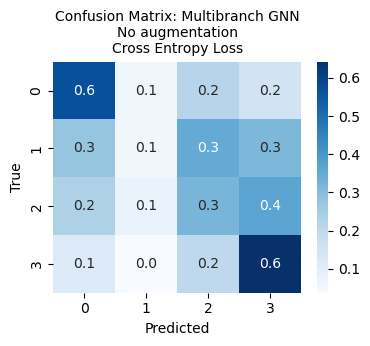





 -- Testing model 2: best_model_multi_branch_gnn_aug_onthefly.pt
 Test results: 

Accuracy: 0.4895
F1-macro: 0.3389
Precision: 0.3476
Recall: 0.3889

Confusion Matrix:


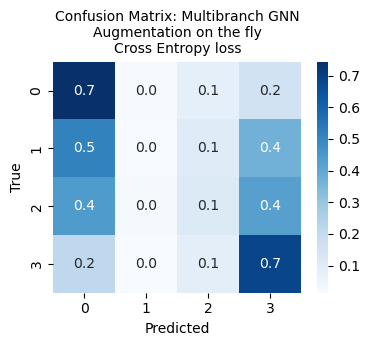





 -- Testing model 3: best_model_multi_branch_gnn_aug_onthefly_focalloss.pt
 Test results: 

Accuracy: 0.5127
F1-macro: 0.3002
Precision: 0.2554
Recall: 0.3694

Confusion Matrix:


/opt/conda/envs/bigdata/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


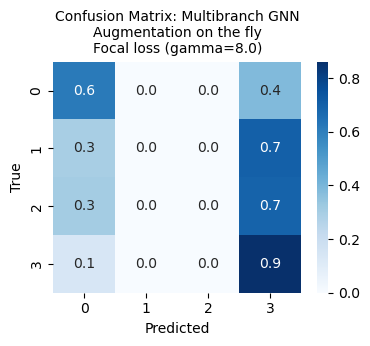

In [ ]:
model_paths = [
    "/workspace/devcontainer-bigdata/models/best_model_multi_branch_gnn.pt",
    "/workspace/devcontainer-bigdata/models/best_model_multi_branch_gnn_aug_onthefly.pt",
    "/workspace/devcontainer-bigdata/models/best_model_multi_branch_gnn_aug_onthefly_focalloss.pt"
]

device = "cuda" if torch.cuda.is_available() else "cpu"

for i, path in enumerate(model_paths):
    print(f"\n -- Testing model {i+1}: {path.split('/')[-1]}")

    # Model architecture
    model = DualHemisphereGNN(
        in_channels=51,
        hidden_channels=best_params['hidden_channels'],
        num_classes=4,
        dropout=0.5,
        num_layers=best_params['num_layers']
    ).to(device)

    # Load the model
    model.load_state_dict(torch.load(path, map_location=device, weights_only=True))
    if "onthefly" in path.split('/')[-1].split('.')[0]:
        if "focalloss" in path.split('/')[-1].split('.')[0]:
            model_name = "Multibranch GNN\nAugmentation on the fly\nFocal loss (gamma=8.0)"
        else:
            model_name = "Multibranch GNN\nAugmentation on the fly\nCross Entropy loss"
    else:
        model_name = "Multibranch GNN\nNo augmentation\nCross Entropy Loss"

    # Evaluation on test
    acc, f1, prec, rec, cm_percent = evaluate_model(model, model_name, test_loader, device)